In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/AER_credit_card_data.csv'

In [3]:
# !wget $data -O data.csv

In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [6]:
card_values = {
    'yes': 1,
    'no': 0
}

df['card'] = df.card.map(card_values)

In [7]:
df.head(10)

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5
5,1,0,23.25000,2.5000,0.044438,91.996670,no,no,0,54,1,1
6,1,0,27.91667,3.9600,0.012576,40.833330,no,no,2,7,1,5
7,1,0,29.16667,2.3700,0.076434,150.790000,yes,no,0,77,1,3
8,1,0,37.00000,3.8000,0.245628,777.821700,yes,no,0,97,1,6
9,1,0,28.41667,3.2000,0.019780,52.580000,no,no,0,65,1,18


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# Spliting the dataset.
df_full_train, df_test = train_test_split(df, test_size= 0.2, random_state=1, shuffle= True)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state= 1, shuffle= True)

df_train = df_train.reset_index(drop= True)
df_val = df_val.reset_index(drop= True)
df_test = df_test.reset_index(drop= True)

y_train = df_train.card.values
y_val = df_val.card.values
y_test = df_test.card.values

del df_train['card']
del df_val['card']
del df_test['card']

In [10]:
print(len(df_train), len(df_val), len(df_test))
print(len(y_train), len(y_val), len(y_test))

791 264 264
791 264 264


In [11]:
df_train.dtypes

reports          int64
age            float64
income         float64
share          float64
expenditure    float64
owner              str
selfemp            str
dependents       int64
months           int64
majorcards       int64
active           int64
dtype: object

In [12]:
# Learning the data.
numerical = ['reports', 'age', 'income', 'share', 'expenditure', 'dependents', 'months', 'majorcards', 'active']
categorical = ['owner', 'selfemp']

In [13]:
from sklearn.metrics import roc_auc_score

In [14]:
for c in numerical:
    auc = roc_auc_score(y_train, df_train[c])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[c])
    print(f"{c}, {auc:.3f}")

reports, 0.717
age, 0.524
income, 0.591
share, 0.989
expenditure, 0.991
dependents, 0.533
months, 0.529
majorcards, 0.534
active, 0.604


In [15]:
# Q1-Ans: share

In [16]:
from sklearn.feature_extraction import DictVectorizer

In [17]:
dv = DictVectorizer(sparse= False)

In [18]:
features = ["reports", "age", "income", "share", "expenditure", "dependents", "months", "majorcards", "active", "owner", "selfemp"]

In [19]:
train_dict = df_train[features].to_dict(orient= 'records')

In [20]:
X_train = dv.fit_transform(train_dict)

In [21]:
X_train[:3]

array([[1.700000e+01, 4.050000e+01, 1.000000e+00, 0.000000e+00,
        4.012800e+00, 1.000000e+00, 1.200000e+01, 1.000000e+00,
        0.000000e+00, 3.000000e+00, 1.000000e+00, 0.000000e+00,
        2.990431e-04],
       [4.000000e+00, 3.233333e+01, 4.000000e+00, 0.000000e+00,
        6.000000e+00, 1.000000e+00, 1.800000e+01, 0.000000e+00,
        1.000000e+00, 1.000000e+00, 1.000000e+00, 0.000000e+00,
        2.000000e-04],
       [7.000000e+00, 2.916667e+01, 0.000000e+00, 6.979333e+01,
        2.200000e+00, 1.000000e+00, 4.900000e+01, 1.000000e+00,
        0.000000e+00, 1.000000e+00, 1.000000e+00, 0.000000e+00,
        3.820546e-02]])

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

In [24]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
def prepare_X(df):
    features = ["reports", "age", "income", "share", "expenditure", "dependents", "months", "majorcards", "active", "owner", "selfemp"]
    dicts = df[features].to_dict(orient= 'records')
    X = dv.transform(dicts)
    return X

In [26]:
X_val = prepare_X(df_val)

In [27]:
y_pred = model.predict_proba(X_val)[:, 1]

In [28]:
y_pred[:5]

array([1.        , 0.05802316, 1.        , 0.01955346, 1.        ])

In [29]:
auc = roc_auc_score(y_val, y_pred)

In [30]:
round(auc, 3)

0.995

In [31]:
# Q2-Ans: 0.995

In [80]:
def precision_recall(y_actual, y_pred, threshold):
    actual_positive = (y_actual == 1)
    actual_negative = (y_actual == 0)

    scores = []

    for t in threshold:
        predicted_positive = (y_pred >= t)
        predicted_negative = (y_pred < t)
        tp = (predicted_positive & actual_positive).sum()
        fp = (predicted_positive & actual_negative).sum()
        fn = (predicted_negative & actual_positive).sum()
        tn = (predicted_negative & actual_negative).sum()

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        scores.append((t, precision, recall))
    return scores

In [81]:
threshold = np.linspace(0, 1, 101)
threshold

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [82]:
output = precision_recall(y_val, y_pred, threshold)

In [83]:
df_pr = pd.DataFrame(output).round(3)
df_pr.columns = ['threshold','precision', 'recall']
df_pr.index = threshold

In [84]:
df_pr[::10]

,threshold,precision,recall
0.0,0.0,0.799,1.000
0.1,0.1,0.925,0.995
0.2,0.2,0.976,0.981
0.3,0.3,0.976,0.972
0.4,0.4,0.995,0.972
0.5,0.5,0.995,0.967
0.6,0.6,0.995,0.967
0.7,0.7,0.995,0.967
0.8,0.8,0.995,0.967
0.9,0.9,1.000,0.967


<Axes: ylabel='precision'>

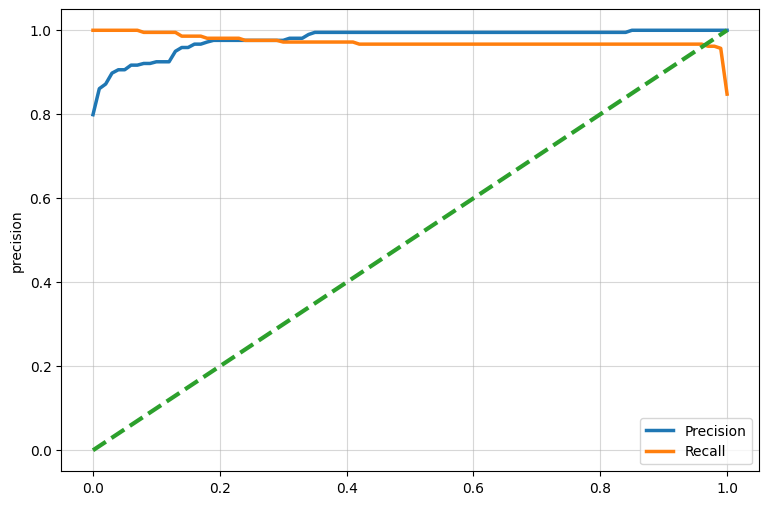

In [85]:
plt.figure(figsize=(9,6))
plt.grid(alpha = 0.5)
sns.lineplot(x=threshold, y=df_pr["precision"], label="Precision", linewidth= 2.5)
sns.lineplot(x=threshold, y=df_pr["recall"], label="Recall", linewidth= 2.5)
sns.lineplot(x=[0,1], y=[0,1], ls = '--', linewidth = 3)

In [86]:
# Q3-Ans:0.3

In [90]:
def f1_score(p_r):
    f1_score = []
    for t, P, R in p_r:
        F1 = 2 * P * R / (P + R)
        f1_score.append((t, F1))
    return f1_score

In [93]:
F1_scores = pd.DataFrame(f1_score(output)).round(3)

In [96]:
F1_scores.columns = ['threshold', 'f1']
F1_scores.index = threshold

In [103]:
F1_scores[::10]

,threshold,f1
0.0,0.0,0.888
0.1,0.1,0.959
0.2,0.2,0.979
0.3,0.3,0.974
0.4,0.4,0.983
0.5,0.5,0.981
0.6,0.6,0.981
0.7,0.7,0.981
0.8,0.8,0.981
0.9,0.9,0.983


In [104]:
F1_scores.loc[F1_scores["f1"].idxmax()]

threshold    0.350
f1           0.983
Name: 0.35000000000000003, dtype: float64

In [105]:
# Q4-Ans: 0.35 or 0.4